In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:

df = pd.read_csv("../data/pre_proccesed_data.csv")
df

,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,50,2,168,62.0,110,80,1,1,0,0,1,0
1,55,1,156,85.0,140,90,3,1,0,0,1,1
2,51,1,165,64.0,130,70,3,1,0,0,0,1
3,48,2,169,82.0,150,100,1,1,0,0,1,1
4,47,1,156,56.0,100,60,1,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
68008,52,2,168,76.0,120,80,1,1,1,0,1,0
68009,61,1,158,126.0,140,90,2,2,0,0,1,1
68010,52,2,183,105.0,180,90,3,1,0,1,0,1
68011,61,1,163,72.0,135,80,1,2,0,0,0,1


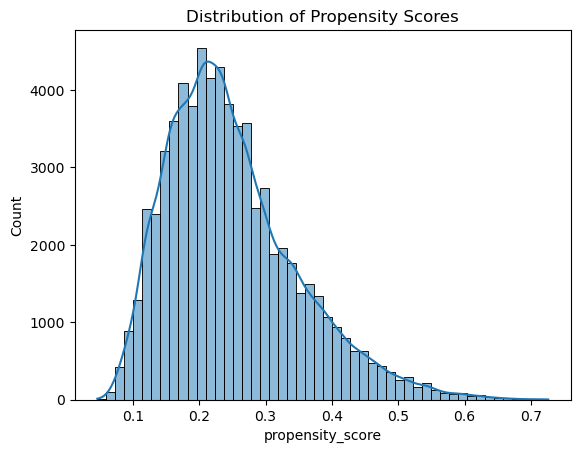

In [3]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import statsmodels.api as sm

# Define Treatment (High Cholesterol)
df['high_chol'] = (df['cholesterol'] >= 2).astype(int)

# Define Confounders (Age, Gender, BP, Smoking, etc.)
confounders = ["age", "gender", "ap_hi", "ap_lo", "smoke", "alco", "active"]

# Logistic Regression for Propensity Score
X = df[confounders]
y = df["high_chol"]

# Standardize Confounders
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Fit Logistic Model
propensity_model = LogisticRegression()
propensity_model.fit(X_scaled, y)

# Get Propensity Scores
df["propensity_score"] = propensity_model.predict_proba(X_scaled)[:, 1]

# Check Distribution
sns.histplot(df["propensity_score"], bins=50, kde=True)
plt.title("Distribution of Propensity Scores")
plt.show()

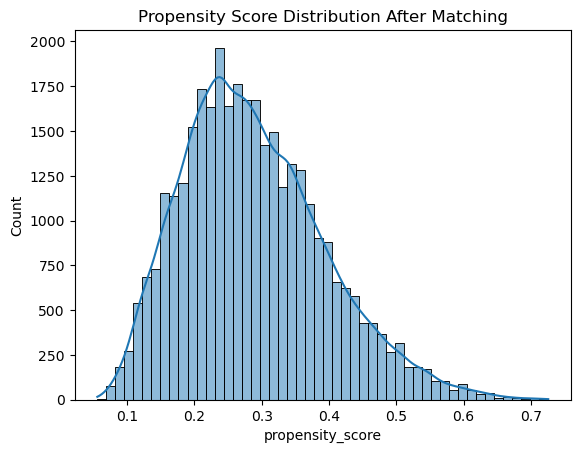

In [4]:
from sklearn.neighbors import NearestNeighbors

# Separate Treated (High Cholesterol) and Control (Normal Cholesterol) Groups
treated = df[df["high_chol"] == 1]
control = df[df["high_chol"] == 0]

# Use Nearest Neighbors to Match
nn = NearestNeighbors(n_neighbors=1, metric="euclidean")
nn.fit(control[["propensity_score"]])
_, indices = nn.kneighbors(treated[["propensity_score"]])

# Create Matched Dataset
matched_control = control.iloc[indices.flatten()]
matched_df = pd.concat([treated, matched_control])

# Check Balance in Propensity Scores After Matching
sns.histplot(matched_df["propensity_score"], bins=50, kde=True)
plt.title("Propensity Score Distribution After Matching")
plt.show()

In [5]:
# Calculating heart disease rates in matched groups
treated_rate = matched_df[matched_df["high_chol"] == 1]["cardio"].mean()
control_rate = matched_df[matched_df["high_chol"] == 0]["cardio"].mean()

# Compute ATT (Causal Effect)
ATT = treated_rate - control_rate

print(f"Heart Disease Rate in High Cholesterol Group: {treated_rate:.3f}")
print(f"Heart Disease Rate in Normal Cholesterol Group: {control_rate:.3f}")
print(f"Estimated Causal Effect (ATT): {ATT:.3f}")

Heart Disease Rate in High Cholesterol Group: 0.671
Heart Disease Rate in Normal Cholesterol Group: 0.595
Estimated Causal Effect (ATT): 0.077


In [6]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Define Features (Excluding 'cardio' as Target)
features = ["age", "gender", "height", "weight", "ap_hi", "ap_lo", "cholesterol", "gluc", "smoke", "alco", "active"]
X = df[features]
y = df["cardio"]  # Target variable

# Split into Train (80%) and Test (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Standardize Numeric Features (Important for Models like Logistic Regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [7]:
X_test

,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active
13515,50,1,158,71.0,150,80,1,1,0,0,1
26837,56,1,163,130.0,180,90,1,1,0,0,1
55134,63,1,166,78.0,140,90,1,3,0,0,1
4887,49,2,165,70.0,130,80,1,1,0,0,0
10320,59,2,155,61.0,140,90,1,1,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...
58710,49,1,164,65.0,120,80,1,1,0,0,1
27410,54,2,169,79.0,150,100,1,1,0,0,0
33417,61,1,168,90.0,140,90,1,1,0,0,1
60293,42,1,156,61.0,120,70,1,1,0,0,0


In [8]:
!pip install xgboost


In [9]:
import xgboost as xgb
print("xgboost", xgb.__version__)

xgboost 3.1.2


In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report

# Train Logistic Regression
log_reg = LogisticRegression()
log_reg.fit(X_train_scaled, y_train)
log_reg_preds = log_reg.predict(X_test_scaled)

# Train Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)

# Train XGBoost
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric="logloss")
xgb_model.fit(X_train, y_train)
xgb_preds = xgb_model.predict(X_test)

# Print Accuracy Scores
print("Logistic Regression Accuracy:", accuracy_score(y_test, log_reg_preds))
print("Random Forest Accuracy:", accuracy_score(y_test, rf_preds))
print("XGBoost Accuracy:", accuracy_score(y_test, xgb_preds))

c:\Users\asusr\anaconda3\Lib\site-packages\xgboost\training.py:199: UserWarning: [21:28:16] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Logistic Regression Accuracy: 0.7268249650812321
Random Forest Accuracy: 0.7096228773064766
XGBoost Accuracy: 0.7331470999044328


XGBoost Classification Report:
               precision    recall  f1-score   support

           0       0.72      0.77      0.75      6886
           1       0.75      0.69      0.72      6717

    accuracy                           0.73     13603
   macro avg       0.73      0.73      0.73     13603
weighted avg       0.73      0.73      0.73     13603



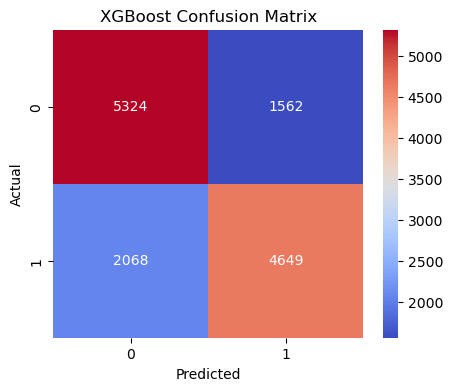

In [11]:
from sklearn.metrics import classification_report, confusion_matrix

# Print Classification Report
print("XGBoost Classification Report:\n", classification_report(y_test, xgb_preds))

# Plot Confusion Matrix
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(5,4))
sns.heatmap(confusion_matrix(y_test, xgb_preds), annot=True, fmt="d", cmap="coolwarm")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("XGBoost Confusion Matrix")
plt.show()

In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report

# Logistic Regression
log_reg = LogisticRegression()
log_reg.fit(X_train_scaled, y_train)
log_reg_preds = log_reg.predict(X_test_scaled)

# Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)

# XGBoost  (Updated code)
xgb_model = XGBClassifier(
    eval_metric="logloss",
    random_state=42
)
xgb_model.fit(X_train, y_train)
xgb_preds = xgb_model.predict(X_test)

# Accuracy
print(f"Logistic Regression Accuracy: {accuracy_score(y_test, log_reg_preds)*100:.2f}%")
print(f"Random Forest Accuracy: {accuracy_score(y_test, rf_preds)*100:.2f}%")
print(f"XGBoost Accuracy:{accuracy_score(y_test, xgb_preds)*100:.2f}%")


Logistic Regression Accuracy: 72.68%
Random Forest Accuracy: 70.96%
XGBoost Accuracy:73.31%


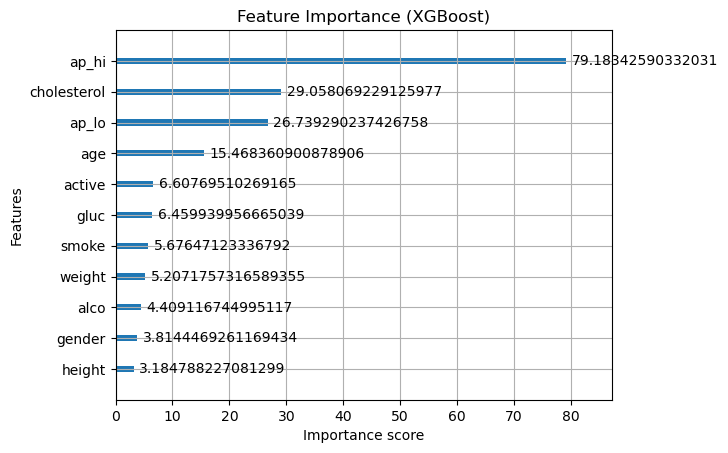

In [13]:
import matplotlib.pyplot as plt
import xgboost as xgb

best_xgb = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    random_state=42
)

best_xgb.fit(X_train, y_train)

# Get feature importance from XGBoost
xgb.plot_importance(best_xgb, importance_type="gain")
plt.title("Feature Importance (XGBoost)")
plt.show()

In [14]:
important_features = ["age", "ap_hi", "ap_lo", "cholesterol", "gluc", "smoke", "alco", "active", "weight"]

X_new = df[important_features]
y = df["cardio"]

X_train_new, X_test_new, y_train_new, y_test_new = train_test_split(
    X_new, y, test_size=0.2, random_state=42, stratify=y
)

best_xgb.fit(X_train_new, y_train_new)
new_preds = best_xgb.predict(X_test_new)

print(f"New XGBoost Accuracy:{accuracy_score(y_test_new, new_preds)*100:.2f}%")
print("New Classification Report:\n", classification_report(y_test_new, new_preds))


New XGBoost Accuracy:73.76%
New Classification Report:
               precision    recall  f1-score   support

           0       0.72      0.78      0.75      6886
           1       0.76      0.69      0.72      6717

    accuracy                           0.74     13603
   macro avg       0.74      0.74      0.74     13603
weighted avg       0.74      0.74      0.74     13603

